## Import libs

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.python.data import Dataset
from tensorflow.keras.optimizers import Adam
import seaborn as sns


from falsb4mpa.modeling.zhang.learning.multi_adv import train_loop as zhang_train
from falsb4mpa.dataset.load_data import load_data
from falsb4mpa.evaluation.evaluation import compute_predictive_metrics, compute_fair_metrics, compute_adv_metrics, compute_tradeoff, fair_evaluation, compute_intersectional_fair_metrics
from falsb4mpa.modeling.zhang.models.multi_adv import ZhangMultAdv

## Preliminaries

In [ ]:
batch_size = 64
epochs = 100
learning_rate = 0.001

In [ ]:
# cv_seeds = [13]
cv_seeds = [13, 29, 42, 55, 73]

## Load data

In [4]:
data_name = 'adult-mpa-cat-wout-agg'

In [5]:
x, y, a1, a2 = load_data(data_name)
raw_data = (x, y, a1, a2)

In [6]:
xdim = x.shape[1]
ydim = y.shape[1]
a1dim = a1.shape[1]
a2dim = a2.shape[1]
zdim = 8
print(xdim, ydim, a1dim, a2dim, zdim)

102 1 1 5 8


## Result file

In [ ]:
header = [
    "model_name", "cv_seed", 
    "clas_acc", "f1-micro", "f1-macro"
    "a1_dp", "a1_deqodds", "a1_deqopp",
    "a2_dp", "a2_deqodds", "a2_deqopp",
    "wc_spd", "wc_aod", "wc_eod",
    "last_cosine_similarity"
]

results = []

## Testing

### DemPar

In [ ]:
fairdef = "DemPar"

for cv_seed in cv_seeds:
    x_train, x_test, y_train, y_test, a1_train, a1_test, a2_train, a2_test = train_test_split(
        x, y, a1, a2, test_size=0.3, random_state=cv_seed)

    train_data = Dataset.from_tensor_slices((x_train, y_train, a1_train, a2_train))
    train_data = train_data.batch(batch_size, drop_remainder=True)

    test_data = Dataset.from_tensor_slices((x_test, y_test, a1_test, a2_test))
    test_data = test_data.batch(batch_size, drop_remainder=True)

    opt = Adam(learning_rate=learning_rate)

    model = ZhangMultAdv(xdim=xdim, ydim=ydim, a1dim=a1dim, a2dim=a2dim, batch_size=batch_size, fairdef=fairdef)
    
    ret, dULa1, dULa2, cos_sim = zhang_train(model, raw_data, train_data, epochs, opt)

    Y, A1, A2, Y_hat, A1_hat, A2_hat = fair_evaluation(model, test_data)
    
    clas_acc, clas_f1_micro, clas_f1_macro, confusion_matrix = compute_predictive_metrics(Y, Y_hat)
    
    adv1_acc = compute_adv_metrics(A1, A1_hat)
    adv2_acc = compute_adv_metrics(A2, A2_hat)
    
    a1_dp, a1_deqodds, a1_deqopp, a1_metrics_g0, a1_metrics_g1 = compute_fair_metrics(Y, A1, Y_hat, a1dim)
    a2_dp, a2_deqodds, a2_deqopp = compute_fair_metrics(Y, A2, Y_hat, a2dim)

    wc_spd, wc_aod, wc_eod = compute_intersectional_fair_metrics(Y, A1, A2, Y_hat, a1dim, a2dim)


    # fair_metrics = (dp, deqodds, deqopp)
    # tradeoff = []
    # for fair_metric in fair_metrics:
    #     tradeoff.append(compute_tradeoff(clas_acc, fair_metric))

    # result = ['Zhang4EqOdds', cv_seed, clas_acc, dp, deqodds, deqopp, tradeoff[0], tradeoff[1], tradeoff[2]] + metrics_a0 + metrics_a1

    result = ['MultAdvCat4DP', cv_seed]
    result += [clas_acc, clas_f1_micro, clas_f1_macro]
    result += [a1_dp, a1_deqodds, a1_deqopp] 
    result += [a2_dp, a2_deqodds, a2_deqopp]
    result += [wc_spd, wc_aod, wc_eod]
    result += [cos_sim]


    results.append(result)

    del(opt, x_train, x_test, y_train, y_test, a1_train, a1_test, a2_train, a2_test, train_data, test_data, model, ret)
    del(Y, A1, A2, Y_hat, A1_hat, A2_hat)
    del(clas_acc, clas_f1_micro, clas_f1_macro, confusion_matrix, adv1_acc, adv2_acc)
    del(a1_dp, a1_deqodds, a1_deqopp, a1_metrics_g0, a1_metrics_g1, a2_dp, a2_deqodds, a2_deqopp)
    del(wc_spd, wc_aod, wc_eod)
    del(cos_sim)

/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/keras/src/optimizers/base_optimizer.py:731: UserWarning: Gradients do not exist for variables ['U:0', 'c:0'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(
2026-05-05 19:19:46.673765: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> Epoch: 1 | Clf loss/acc 0.76/0.25 | Adv1 loss/acc 0.67/0.67 | Adv2 loss/acc 1.57/0.86


2026-05-05 19:20:03.037361: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> Epoch: 2 | Clf loss/acc 0.58/0.61 | Adv1 loss/acc 0.67/0.67 | Adv2 loss/acc 1.58/0.86
> Epoch: 3 | Clf loss/acc 0.50/0.75 | Adv1 loss/acc 0.67/0.67 | Adv2 loss/acc 1.58/0.86


2026-05-05 19:20:35.310528: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


...

> Epoch: 16 | Clf loss/acc 0.34/0.83 | Adv1 loss/acc 0.68/0.67 | Adv2 loss/acc 1.44/0.86
> Epoch: 17 | Clf loss/acc 0.34/0.83 | Adv1 loss/acc 0.68/0.67 | Adv2 loss/acc 1.42/0.86
> Epoch: 18 | Clf loss/acc 0.34/0.83 | Adv1 loss/acc 0.68/0.67 | Adv2 loss/acc 1.41/0.86
> Epoch: 19 | Clf loss/acc 0.34/0.83 | Adv1 loss/acc 0.68/0.67 | Adv2 loss/acc 1.40/0.86
> Epoch: 20 | Clf loss/acc 0.33/0.83 | Adv1 loss/acc 0.68/0.67 | Adv2 loss/acc 1.38/0.86
> Epoch: 21 | Clf loss/acc 0.33/0.83 | Adv1 loss/acc 0.69/0.67 | Adv2 loss/acc 1.37/0.86
> Epoch: 22 | Clf loss/acc 0.33/0.83 | Adv1 loss/acc 0.69/0.67 | Adv2 loss/acc 1.36/0.86
> Epoch: 23 | Clf loss/acc 0.33/0.83 | Adv1 loss/acc 0.69/0.67 | Adv2 loss/acc 1.34/0.86
> Epoch: 24 | Clf loss/acc 0.33/0.83 | Adv1 loss/acc 0.69/0.67 | Adv2 loss/acc 1.34/0.86
> Epoch: 25 | Clf loss/acc 0.33/0.83 | Adv1 loss/acc 0.69/0.67 | Adv2 loss/acc 1.33/0.86
> Epoch: 26 | Clf loss/acc 0.33/0.83 | Adv1 loss/acc 0.70/0.67 | Adv2 loss/acc 1.32/0.86
> Epoch: 27 | Clf los

2026-05-05 19:28:05.467241: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> Epoch: 32 | Clf loss/acc 0.33/0.83 | Adv1 loss/acc 0.71/0.67 | Adv2 loss/acc 1.28/0.86
> Epoch: 33 | Clf loss/acc 0.33/0.83 | Adv1 loss/acc 0.72/0.67 | Adv2 loss/acc 1.28/0.86
> Epoch: 34 | Clf loss/acc 0.33/0.83 | Adv1 loss/acc 0.72/0.67 | Adv2 loss/acc 1.27/0.86
> Epoch: 35 | Clf loss/acc 0.33/0.83 | Adv1 loss/acc 0.72/0.67 | Adv2 loss/acc 1.27/0.86
> Epoch: 36 | Clf loss/acc 0.33/0.83 | Adv1 loss/acc 0.73/0.67 | Adv2 loss/acc 1.26/0.86
> Epoch: 37 | Clf loss/acc 0.33/0.83 | Adv1 loss/acc 0.73/0.67 | Adv2 loss/acc 1.26/0.86
> Epoch: 38 | Clf loss/acc 0.33/0.83 | Adv1 loss/acc 0.74/0.67 | Adv2 loss/acc 1.26/0.86
> Epoch: 39 | Clf loss/acc 0.33/0.83 | Adv1 loss/acc 0.74/0.67 | Adv2 loss/acc 1.25/0.86
> Epoch: 40 | Clf loss/acc 0.33/0.83 | Adv1 loss/acc 0.74/0.67 | Adv2 loss/acc 1.25/0.86
> Epoch: 41 | Clf loss/acc 0.33/0.83 | Adv1 loss/acc 0.75/0.67 | Adv2 loss/acc 1.25/0.86
> Epoch: 42 | Clf loss/acc 0.33/0.83 | Adv1 loss/acc 0.75/0.67 | Adv2 loss/acc 1.24/0.86
> Epoch: 43 | Clf los

2026-05-05 19:36:41.443931: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> Epoch: 64 | Clf loss/acc 0.35/0.83 | Adv1 loss/acc 0.85/0.67 | Adv2 loss/acc 1.21/0.86
> Epoch: 65 | Clf loss/acc 0.35/0.83 | Adv1 loss/acc 0.86/0.67 | Adv2 loss/acc 1.21/0.86
> Epoch: 66 | Clf loss/acc 0.35/0.83 | Adv1 loss/acc 0.86/0.67 | Adv2 loss/acc 1.21/0.86
> Epoch: 67 | Clf loss/acc 0.35/0.83 | Adv1 loss/acc 0.87/0.67 | Adv2 loss/acc 1.21/0.86
> Epoch: 68 | Clf loss/acc 0.35/0.83 | Adv1 loss/acc 0.87/0.67 | Adv2 loss/acc 1.21/0.86
> Epoch: 69 | Clf loss/acc 0.35/0.83 | Adv1 loss/acc 0.88/0.67 | Adv2 loss/acc 1.21/0.86
> Epoch: 70 | Clf loss/acc 0.35/0.83 | Adv1 loss/acc 0.88/0.67 | Adv2 loss/acc 1.21/0.86
> Epoch: 71 | Clf loss/acc 0.35/0.84 | Adv1 loss/acc 0.89/0.67 | Adv2 loss/acc 1.21/0.86
> Epoch: 72 | Clf loss/acc 0.35/0.84 | Adv1 loss/acc 0.90/0.67 | Adv2 loss/acc 1.21/0.86
> Epoch: 73 | Clf loss/acc 0.36/0.84 | Adv1 loss/acc 0.90/0.67 | Adv2 loss/acc 1.21/0.86
> Epoch: 74 | Clf loss/acc 0.36/0.84 | Adv1 loss/acc 0.91/0.67 | Adv2 loss/acc 1.21/0.86
> Epoch: 75 | Clf los

In [9]:
print(clas_acc, clas_f1_micro, clas_f1_macro)

0.83619666 0.836196682464455 0.7749195965094313


<Axes: >

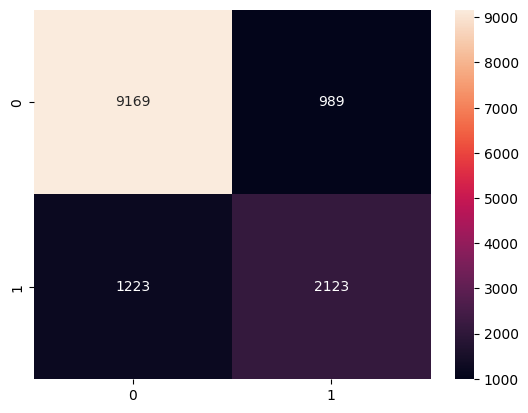

In [10]:
sns.heatmap(confusion_matrix, annot=True, fmt='g')

### EqOdds

In [ ]:
fairdef = "EqOdds"

for cv_seed in cv_seeds:
    x_train, x_test, y_train, y_test, a1_train, a1_test, a2_train, a2_test = train_test_split(
        x, y, a1, a2, test_size=0.3, random_state=cv_seed)

    train_data = Dataset.from_tensor_slices((x_train, y_train, a1_train, a2_train))
    train_data = train_data.batch(batch_size, drop_remainder=True)

    test_data = Dataset.from_tensor_slices((x_test, y_test, a1_test, a2_test))
    test_data = test_data.batch(batch_size, drop_remainder=True)

    opt = Adam(learning_rate=learning_rate)

    model = ZhangMultAdv(xdim=xdim, ydim=ydim, a1dim=a1dim, a2dim=a2dim, batch_size=batch_size, fairdef=fairdef)
    
    ret, dULa1, dULa2, cos_sim = zhang_train(model, raw_data, train_data, epochs, opt)

    Y, A1, A2, Y_hat, A1_hat, A2_hat = fair_evaluation(model, test_data)
    
    clas_acc, clas_f1_micro, clas_f1_macro, confusion_matrix = compute_predictive_metrics(Y, Y_hat)
    
    adv1_acc = compute_adv_metrics(A1, A1_hat)
    adv2_acc = compute_adv_metrics(A2, A2_hat)
    
    a1_dp, a1_deqodds, a1_deqopp, a1_metrics_g0, a1_metrics_g1 = compute_fair_metrics(Y, A1, Y_hat, a1dim)
    a2_dp, a2_deqodds, a2_deqopp = compute_fair_metrics(Y, A2, Y_hat, a2dim)

    wc_spd, wc_aod, wc_eod = compute_intersectional_fair_metrics(Y, A1, A2, Y_hat, a1dim, a2dim)


    # fair_metrics = (dp, deqodds, deqopp)
    # tradeoff = []
    # for fair_metric in fair_metrics:
    #     tradeoff.append(compute_tradeoff(clas_acc, fair_metric))

    # result = ['Zhang4EqOdds', cv_seed, clas_acc, dp, deqodds, deqopp, tradeoff[0], tradeoff[1], tradeoff[2]] + metrics_a0 + metrics_a1

    result = ['MultAdvCat4EqOdds', cv_seed]
    result += [clas_acc, clas_f1_micro, clas_f1_macro]
    result += [a1_dp, a1_deqodds, a1_deqopp] 
    result += [a2_dp, a2_deqodds, a2_deqopp]
    result += [wc_spd, wc_aod, wc_eod]
    result += [cos_sim]


    results.append(result)

    del(opt, x_train, x_test, y_train, y_test, a1_train, a1_test, a2_train, a2_test, train_data, test_data, model, ret)
    del(Y, A1, A2, Y_hat, A1_hat, A2_hat)
    del(clas_acc, clas_f1_micro, clas_f1_macro, confusion_matrix, adv1_acc, adv2_acc)
    del(a1_dp, a1_deqodds, a1_deqopp, a1_metrics_g0, a1_metrics_g1, a2_dp, a2_deqodds, a2_deqopp)
    del(wc_spd, wc_aod, wc_eod)
    del(cos_sim)

/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/keras/src/optimizers/base_optimizer.py:731: UserWarning: Gradients do not exist for variables ['U:0', 'c:0'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


> Epoch: 1 | Clf loss/acc 0.76/0.25 | Adv1 loss/acc 0.67/0.67 | Adv2 loss/acc 1.54/0.86
> Epoch: 2 | Clf loss/acc 0.58/0.61 | Adv1 loss/acc 0.67/0.67 | Adv2 loss/acc 1.54/0.86
> Epoch: 3 | Clf loss/acc 0.50/0.76 | Adv1 loss/acc 0.67/0.67 | Adv2 loss/acc 1.55/0.86
> Epoch: 4 | Clf loss/acc 0.46/0.76 | Adv1 loss/acc 0.67/0.67 | Adv2 loss/acc 1.54/0.86
> Epoch: 5 | Clf loss/acc 0.43/0.78 | Adv1 loss/acc 0.67/0.67 | Adv2 loss/acc 1.52/0.86
> Epoch: 6 | Clf loss/acc 0.41/0.80 | Adv1 loss/acc 0.67/0.67 | Adv2 loss/acc 1.50/0.86
> Epoch: 7 | Clf loss/acc 0.39/0.81 | Adv1 loss/acc 0.67/0.67 | Adv2 loss/acc 1.48/0.86
> Epoch: 8 | Clf loss/acc 0.38/0.82 | Adv1 loss/acc 0.67/0.67 | Adv2 loss/acc 1.46/0.86
> Epoch: 9 | Clf loss/acc 0.37/0.82 | Adv1 loss/acc 0.67/0.67 | Adv2 loss/acc 1.44/0.86
> Epoch: 10 | Clf loss/acc 0.37/0.82 | Adv1 loss/acc 0.67/0.67 | Adv2 loss/acc 1.42/0.86
> Epoch: 11 | Clf loss/acc 0.36/0.82 | Adv1 loss/acc 0.67/0.67 | Adv2 loss/acc 1.41/0.86
> Epoch: 12 | Clf loss/acc 0.3

2026-05-05 19:54:30.994157: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> Epoch: 27 | Clf loss/acc 0.33/0.83 | Adv1 loss/acc 0.70/0.67 | Adv2 loss/acc 1.20/0.86
> Epoch: 28 | Clf loss/acc 0.33/0.83 | Adv1 loss/acc 0.71/0.67 | Adv2 loss/acc 1.20/0.86
> Epoch: 29 | Clf loss/acc 0.33/0.83 | Adv1 loss/acc 0.71/0.67 | Adv2 loss/acc 1.20/0.86
> Epoch: 30 | Clf loss/acc 0.33/0.83 | Adv1 loss/acc 0.71/0.67 | Adv2 loss/acc 1.20/0.86
> Epoch: 31 | Clf loss/acc 0.33/0.83 | Adv1 loss/acc 0.71/0.67 | Adv2 loss/acc 1.19/0.86
> Epoch: 32 | Clf loss/acc 0.33/0.83 | Adv1 loss/acc 0.72/0.67 | Adv2 loss/acc 1.19/0.86
> Epoch: 33 | Clf loss/acc 0.33/0.83 | Adv1 loss/acc 0.72/0.67 | Adv2 loss/acc 1.19/0.86
> Epoch: 34 | Clf loss/acc 0.33/0.83 | Adv1 loss/acc 0.72/0.67 | Adv2 loss/acc 1.19/0.86
> Epoch: 35 | Clf loss/acc 0.33/0.83 | Adv1 loss/acc 0.73/0.67 | Adv2 loss/acc 1.19/0.86
> Epoch: 36 | Clf loss/acc 0.33/0.83 | Adv1 loss/acc 0.73/0.67 | Adv2 loss/acc 1.19/0.86
> Epoch: 37 | Clf loss/acc 0.33/0.83 | Adv1 loss/acc 0.74/0.67 | Adv2 loss/acc 1.19/0.86
> Epoch: 38 | Clf los

In [12]:
print(clas_acc, clas_f1_micro, clas_f1_macro)

0.83612263 0.8361226303317536 0.7745543084948654


<Axes: >

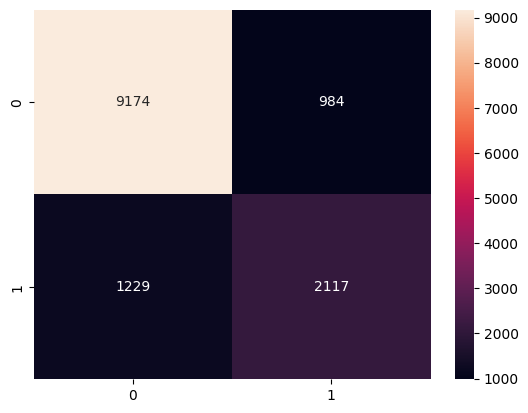

In [13]:
sns.heatmap(confusion_matrix, annot=True, fmt='g')

### EqOpp

In [ ]:
fairdef = "EqOpp"

for cv_seed in cv_seeds:
    x_train, x_test, y_train, y_test, a1_train, a1_test, a2_train, a2_test = train_test_split(
        x, y, a1, a2, test_size=0.3, random_state=cv_seed)

    train_data = Dataset.from_tensor_slices((x_train, y_train, a1_train, a2_train))
    train_data = train_data.batch(batch_size, drop_remainder=True)

    test_data = Dataset.from_tensor_slices((x_test, y_test, a1_test, a2_test))
    test_data = test_data.batch(batch_size, drop_remainder=True)

    opt = Adam(learning_rate=learning_rate)

    model = ZhangMultAdv(xdim=xdim, ydim=ydim, a1dim=a1dim, a2dim=a2dim, batch_size=batch_size, fairdef=fairdef)
    
    ret, dULa1, dULa2, cos_sim = zhang_train(model, raw_data, train_data, epochs, opt)

    Y, A1, A2, Y_hat, A1_hat, A2_hat = fair_evaluation(model, test_data)
    
    clas_acc, clas_f1_micro, clas_f1_macro, confusion_matrix = compute_predictive_metrics(Y, Y_hat)
    
    adv1_acc = compute_adv_metrics(A1, A1_hat)
    adv2_acc = compute_adv_metrics(A2, A2_hat)
    
    a1_dp, a1_deqodds, a1_deqopp, a1_metrics_g0, a1_metrics_g1 = compute_fair_metrics(Y, A1, Y_hat, a1dim)
    a2_dp, a2_deqodds, a2_deqopp = compute_fair_metrics(Y, A2, Y_hat, a2dim)

    wc_spd, wc_aod, wc_eod = compute_intersectional_fair_metrics(Y, A1, A2, Y_hat, a1dim, a2dim)


    # fair_metrics = (dp, deqodds, deqopp)
    # tradeoff = []
    # for fair_metric in fair_metrics:
    #     tradeoff.append(compute_tradeoff(clas_acc, fair_metric))

    # result = ['Zhang4EqOdds', cv_seed, clas_acc, dp, deqodds, deqopp, tradeoff[0], tradeoff[1], tradeoff[2]] + metrics_a0 + metrics_a1

    result = ['MultAdv4EqOpp', cv_seed]
    result += [clas_acc, clas_f1_micro, clas_f1_macro]
    result += [a1_dp, a1_deqodds, a1_deqopp] 
    result += [a2_dp, a2_deqodds, a2_deqopp]
    result += [wc_spd, wc_aod, wc_eod]
    result += [cos_sim]


    results.append(result)

    del(opt, x_train, x_test, y_train, y_test, a1_train, a1_test, a2_train, a2_test, train_data, test_data, model, ret)
    del(Y, A1, A2, Y_hat, A1_hat, A2_hat)
    del(clas_acc, clas_f1_micro, clas_f1_macro, confusion_matrix, adv1_acc, adv2_acc)
    del(a1_dp, a1_deqodds, a1_deqopp, a1_metrics_g0, a1_metrics_g1, a2_dp, a2_deqodds, a2_deqopp)
    del(wc_spd, wc_aod, wc_eod)
    del(cos_sim)

/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/keras/src/optimizers/base_optimizer.py:731: UserWarning: Gradients do not exist for variables ['U:0', 'c:0'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(
2026-05-06 08:53:58.532146: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> Epoch: 1 | Clf loss/acc 0.75/0.25 | Adv1 loss/acc 0.12/0.67 | Adv2 loss/acc 0.34/0.86


2026-05-06 08:54:16.733569: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> Epoch: 2 | Clf loss/acc 0.57/0.64 | Adv1 loss/acc 0.12/0.67 | Adv2 loss/acc 0.34/0.86
> Epoch: 3 | Clf loss/acc 0.49/0.75 | Adv1 loss/acc 0.12/0.67 | Adv2 loss/acc 0.33/0.86


2026-05-06 08:54:53.423215: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


...

> Epoch: 16 | Clf loss/acc 0.34/0.83 | Adv1 loss/acc 0.10/0.67 | Adv2 loss/acc 0.22/0.86
> Epoch: 17 | Clf loss/acc 0.33/0.83 | Adv1 loss/acc 0.10/0.67 | Adv2 loss/acc 0.22/0.86
> Epoch: 18 | Clf loss/acc 0.33/0.83 | Adv1 loss/acc 0.10/0.67 | Adv2 loss/acc 0.21/0.86
> Epoch: 19 | Clf loss/acc 0.33/0.83 | Adv1 loss/acc 0.10/0.67 | Adv2 loss/acc 0.21/0.86
> Epoch: 20 | Clf loss/acc 0.33/0.83 | Adv1 loss/acc 0.10/0.67 | Adv2 loss/acc 0.21/0.86
> Epoch: 21 | Clf loss/acc 0.33/0.83 | Adv1 loss/acc 0.10/0.67 | Adv2 loss/acc 0.20/0.86
> Epoch: 22 | Clf loss/acc 0.33/0.83 | Adv1 loss/acc 0.10/0.67 | Adv2 loss/acc 0.20/0.86
> Epoch: 23 | Clf loss/acc 0.32/0.83 | Adv1 loss/acc 0.10/0.67 | Adv2 loss/acc 0.19/0.86
> Epoch: 24 | Clf loss/acc 0.32/0.83 | Adv1 loss/acc 0.10/0.67 | Adv2 loss/acc 0.19/0.86
> Epoch: 25 | Clf loss/acc 0.32/0.83 | Adv1 loss/acc 0.10/0.67 | Adv2 loss/acc 0.19/0.86
> Epoch: 26 | Clf loss/acc 0.32/0.83 | Adv1 loss/acc 0.10/0.67 | Adv2 loss/acc 0.19/0.86
> Epoch: 27 | Clf los

2026-05-06 09:03:36.682921: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> Epoch: 32 | Clf loss/acc 0.32/0.83 | Adv1 loss/acc 0.10/0.65 | Adv2 loss/acc 0.18/0.86
> Epoch: 33 | Clf loss/acc 0.32/0.83 | Adv1 loss/acc 0.10/0.65 | Adv2 loss/acc 0.18/0.86
> Epoch: 34 | Clf loss/acc 0.32/0.83 | Adv1 loss/acc 0.10/0.64 | Adv2 loss/acc 0.18/0.86
> Epoch: 35 | Clf loss/acc 0.32/0.83 | Adv1 loss/acc 0.10/0.64 | Adv2 loss/acc 0.18/0.86
> Epoch: 36 | Clf loss/acc 0.32/0.83 | Adv1 loss/acc 0.10/0.63 | Adv2 loss/acc 0.18/0.86
> Epoch: 37 | Clf loss/acc 0.32/0.83 | Adv1 loss/acc 0.10/0.63 | Adv2 loss/acc 0.18/0.86
> Epoch: 38 | Clf loss/acc 0.32/0.83 | Adv1 loss/acc 0.10/0.62 | Adv2 loss/acc 0.18/0.86
> Epoch: 39 | Clf loss/acc 0.32/0.83 | Adv1 loss/acc 0.10/0.62 | Adv2 loss/acc 0.18/0.86
> Epoch: 40 | Clf loss/acc 0.33/0.83 | Adv1 loss/acc 0.10/0.61 | Adv2 loss/acc 0.18/0.86
> Epoch: 41 | Clf loss/acc 0.33/0.83 | Adv1 loss/acc 0.11/0.61 | Adv2 loss/acc 0.18/0.86
> Epoch: 42 | Clf loss/acc 0.33/0.83 | Adv1 loss/acc 0.11/0.61 | Adv2 loss/acc 0.18/0.86
> Epoch: 43 | Clf los

2026-05-06 09:13:36.427133: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> Epoch: 64 | Clf loss/acc 0.35/0.83 | Adv1 loss/acc 0.11/0.56 | Adv2 loss/acc 0.18/0.86
> Epoch: 65 | Clf loss/acc 0.35/0.83 | Adv1 loss/acc 0.12/0.56 | Adv2 loss/acc 0.18/0.86
> Epoch: 66 | Clf loss/acc 0.35/0.83 | Adv1 loss/acc 0.12/0.55 | Adv2 loss/acc 0.18/0.86
> Epoch: 67 | Clf loss/acc 0.35/0.83 | Adv1 loss/acc 0.12/0.55 | Adv2 loss/acc 0.18/0.86
> Epoch: 68 | Clf loss/acc 0.35/0.83 | Adv1 loss/acc 0.12/0.55 | Adv2 loss/acc 0.18/0.86
> Epoch: 69 | Clf loss/acc 0.35/0.83 | Adv1 loss/acc 0.12/0.55 | Adv2 loss/acc 0.18/0.86
> Epoch: 70 | Clf loss/acc 0.35/0.83 | Adv1 loss/acc 0.12/0.55 | Adv2 loss/acc 0.18/0.86
> Epoch: 71 | Clf loss/acc 0.35/0.83 | Adv1 loss/acc 0.12/0.55 | Adv2 loss/acc 0.18/0.86
> Epoch: 72 | Clf loss/acc 0.36/0.83 | Adv1 loss/acc 0.12/0.55 | Adv2 loss/acc 0.18/0.86
> Epoch: 73 | Clf loss/acc 0.36/0.83 | Adv1 loss/acc 0.12/0.55 | Adv2 loss/acc 0.18/0.86
> Epoch: 74 | Clf loss/acc 0.36/0.83 | Adv1 loss/acc 0.12/0.54 | Adv2 loss/acc 0.18/0.86
> Epoch: 75 | Clf los

In [9]:
print(clas_acc, clas_f1_micro, clas_f1_macro)

0.833827 0.8338270142180095 0.7696959692544674


<Axes: >

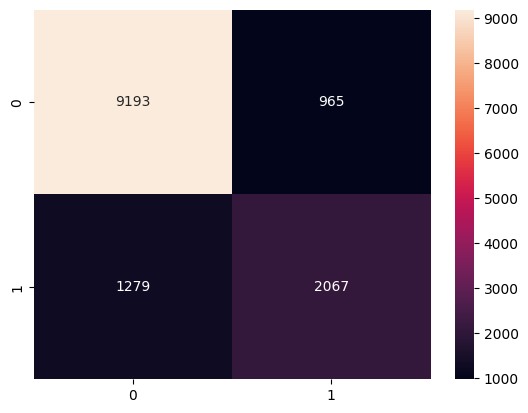

In [10]:
sns.heatmap(confusion_matrix, annot=True, fmt='g')

## Saving into DF then CSV

In [ ]:
result_df = pd.DataFrame(results, columns=header)
result_df

In [ ]:
result_df.to_csv(f'../results/{data_name}-result/mult_adv-{epochs}.csv')